In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


In [55]:
df = pd.read_csv("/content/drive/MyDrive/Estudos - Hard Skills/Cases/Projeto 2 - Precificação de Casas/train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [57]:
base = df.copy()
base.drop('Id', axis = 1,inplace = True)
base

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Dados Faltantes:


Alley = Beco/Viela -> NaN = Não tem beco ou viela

LotFrontage = Distância entre a frente da casa e a rua -> NaN = Substituir pela mediana por vizinho (casas da mesma vizinhança tendem a ter o mesmo LotFrontage)

MasVnrType = Revestimento da Casa -> NaN = Não tem Revestimento

PoolQC = Qualidade da Piscina -> NaN = Não tem piscina

Fence = Qualidade da cerca -> Nan = Não tem cerca

MiscFeature = Caracteristicas Especiais da Casa (Ex: Galpão)
-> Nan = Não tem características

Basmt = Porção -> Nan = Não tem








Tratando Dados Faltantes:

In [58]:
base.Alley.fillna('Nao_Tem', inplace = True)
base.LotFrontage.fillna(base.groupby('Neighborhood')['LotFrontage'].transform('median'), inplace = True)
base.MasVnrType.fillna('Nao_Tem', inplace = True)
base.PoolQC.fillna('Nao_Tem', inplace = True)
base.Fence.fillna('Nao_Tem', inplace = True)
base.MiscFeature.fillna('Nao_Tem', inplace = True)
base.FireplaceQu.fillna('Nao_Tem', inplace = True)

porao = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']
for i in porao:
  base[i].fillna('Nao_Tem', inplace = True)


garagem = ['GarageType','GarageYrBlt','GarageFinish','GarageCars','GarageQual','GarageCond']
for i in garagem:
  base[i].fillna('Nao_Tem', inplace = True)




/tmp/ipython-input-1554609346.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  base.Alley.fillna('Nao_Tem', inplace = True)
/tmp/ipython-input-1554609346.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [59]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

/tmp/ipython-input-3348043587.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(base["SalePrice"])


Text(0, 0.5, 'Distribuição de Frequencia')

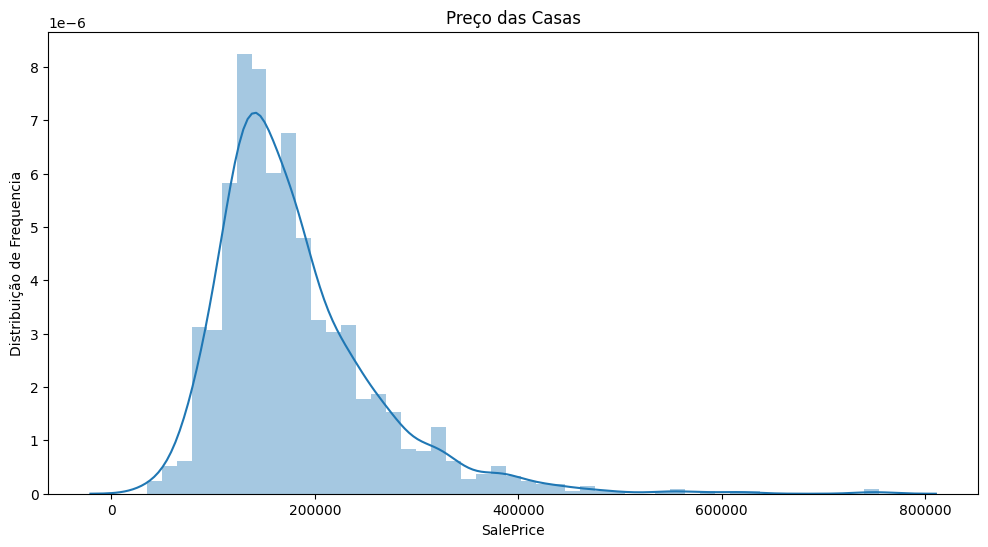

In [60]:
#Criando histograma dos preços da casa:

ax = sns.distplot(base["SalePrice"])
ax.figure.set_size_inches(12,6)
ax.set_title('Preço das Casas')
ax.set_ylabel("Distribuição de Frequencia")


In [61]:
base['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


## ANÁLISE VARIÁVEIS QUANTITATIVAS:

In [62]:


base_num = base.select_dtypes(include=['float64', 'int64'])
base_num.head()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


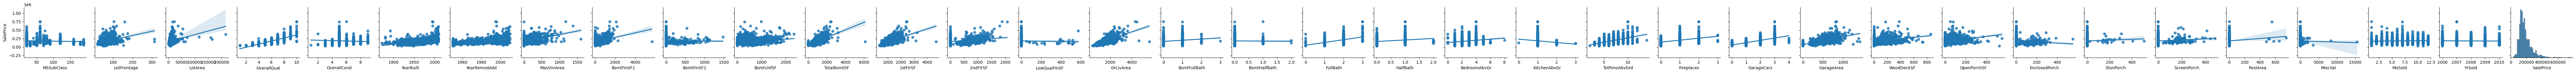

In [63]:
#Análise Variáveis Quantitaitvas x Preço:

ax = sns.pairplot(base_num, y_vars='SalePrice', x_vars=base_num, kind = "reg")

Variáveis Quantitativas com boa correlação no preço

OverallQual

YearBuilt

Total BsmtSF

1stFirSF

GrLivArea

FullBath
## Nova seção
GarageArea

<Axes: >

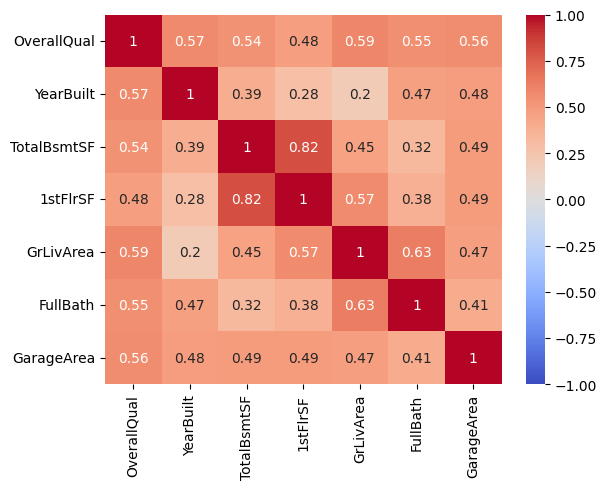

In [64]:
#Verificando se a dependência entre elas via correlação de pearson:

candidatas = ['OverallQual','YearBuilt','TotalBsmtSF','1stFlrSF','GrLivArea','FullBath','GarageArea']
sns.heatmap(base_num[candidatas].corr(), annot = True, vmin = -1, vmax = 1, cmap = "coolwarm" )


Total BsmtSF e 1stFlrSF tem correlação muito alta, portanto entrara só a Total

## ANÁLISE VARIÁVEIS QUALITATIVAS:

In [65]:
base_text =  base.select_dtypes(include=[object])
base_text.head(3)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,Nao_Tem,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,2003.0,RFn,TA,TA,Y,Nao_Tem,Nao_Tem,Nao_Tem,WD,Normal
1,RL,Pave,Nao_Tem,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,1976.0,RFn,TA,TA,Y,Nao_Tem,Nao_Tem,Nao_Tem,WD,Normal
2,RL,Pave,Nao_Tem,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,2001.0,RFn,TA,TA,Y,Nao_Tem,Nao_Tem,Nao_Tem,WD,Normal


In [66]:
#Adicionando a Variável Resposta Preço:

base_text['SalePrice'] = df['SalePrice']

base_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 45 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSZoning       1460 non-null   object
 1   Street         1460 non-null   object
 2   Alley          1460 non-null   object
 3   LotShape       1460 non-null   object
 4   LandContour    1460 non-null   object
 5   Utilities      1460 non-null   object
 6   LotConfig      1460 non-null   object
 7   LandSlope      1460 non-null   object
 8   Neighborhood   1460 non-null   object
 9   Condition1     1460 non-null   object
 10  Condition2     1460 non-null   object
 11  BldgType       1460 non-null   object
 12  HouseStyle     1460 non-null   object
 13  RoofStyle      1460 non-null   object
 14  RoofMatl       1460 non-null   object
 15  Exterior1st    1460 non-null   object
 16  Exterior2nd    1460 non-null   object
 17  MasVnrType     1460 non-null   object
 18  ExterQual      1460 non-null

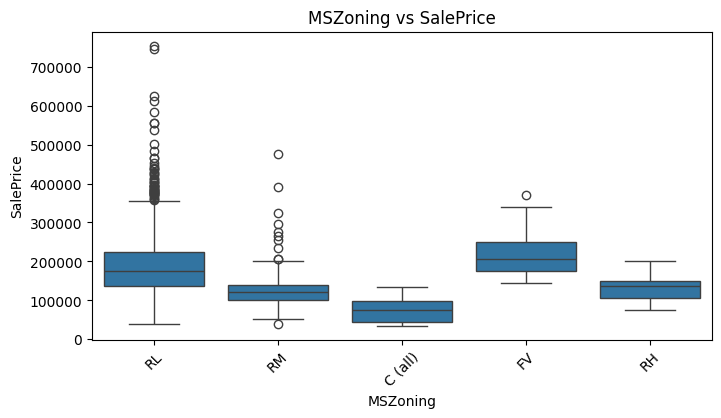

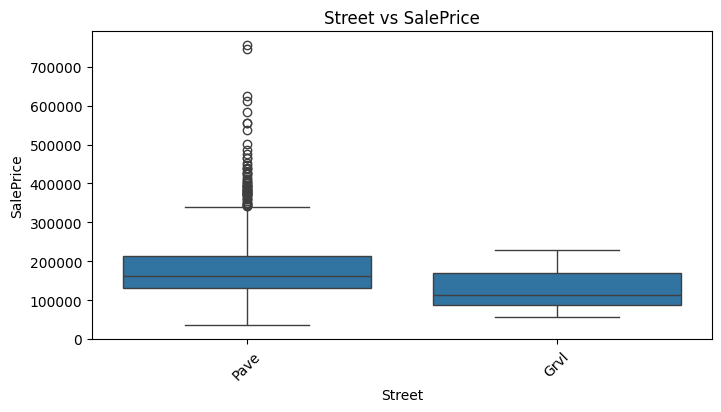

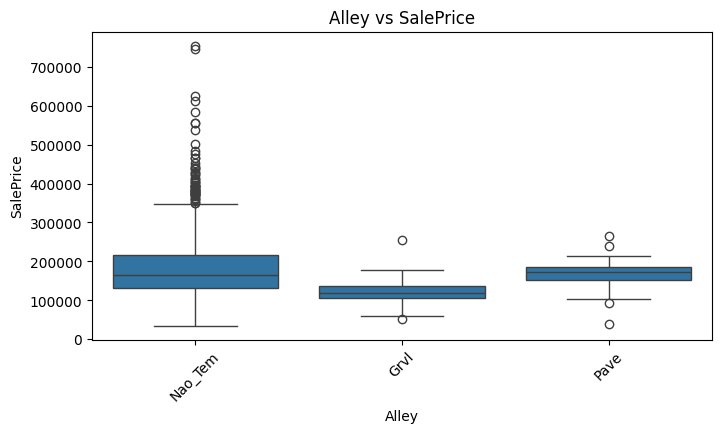

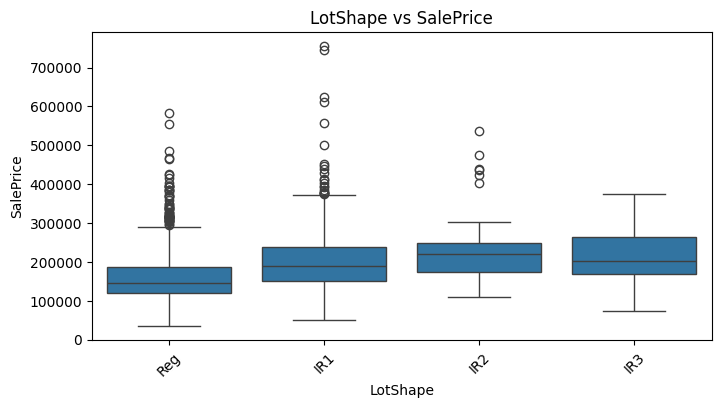

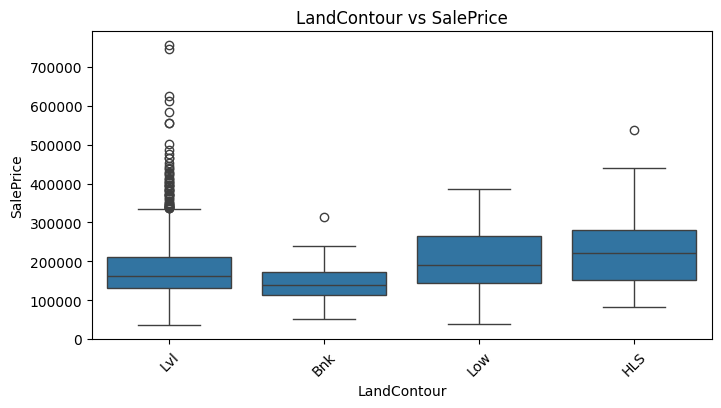

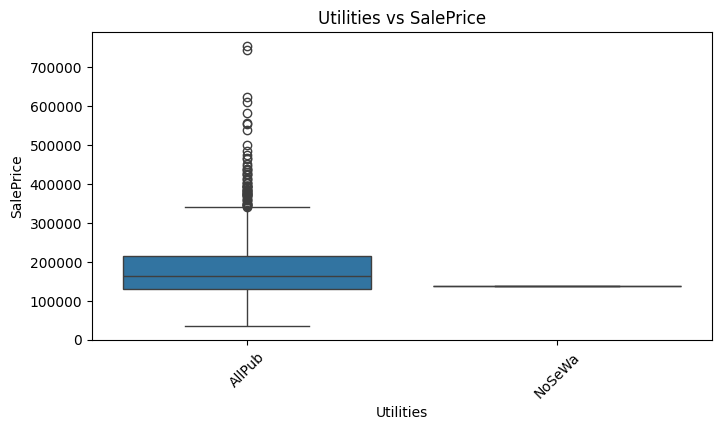

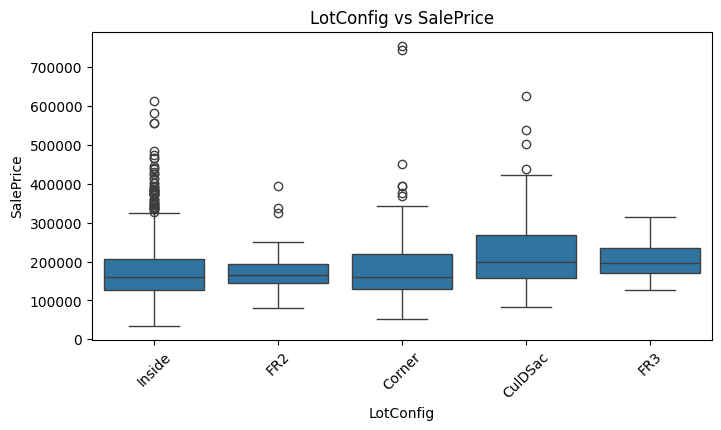

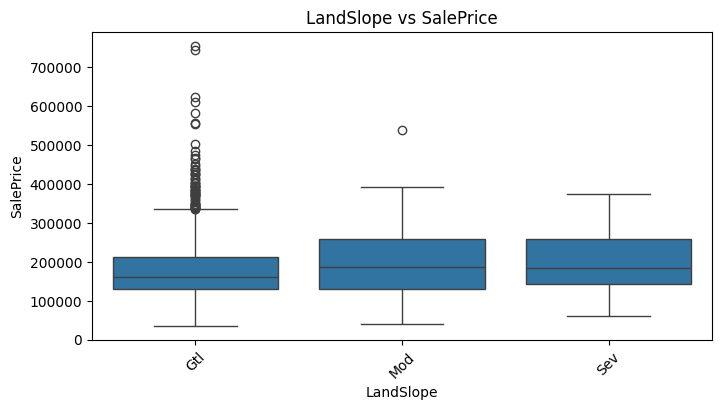

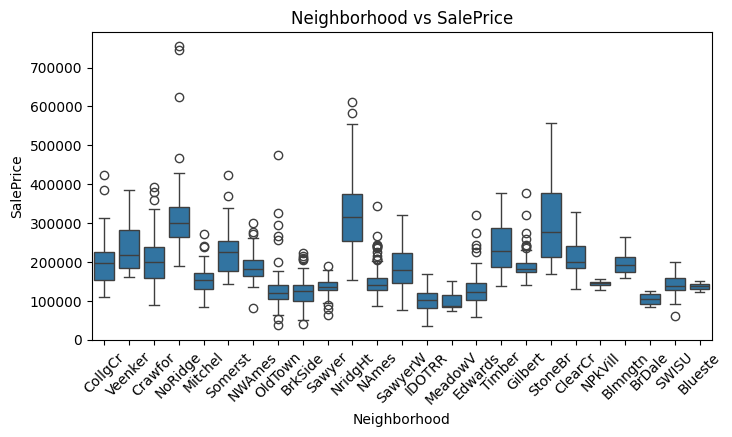

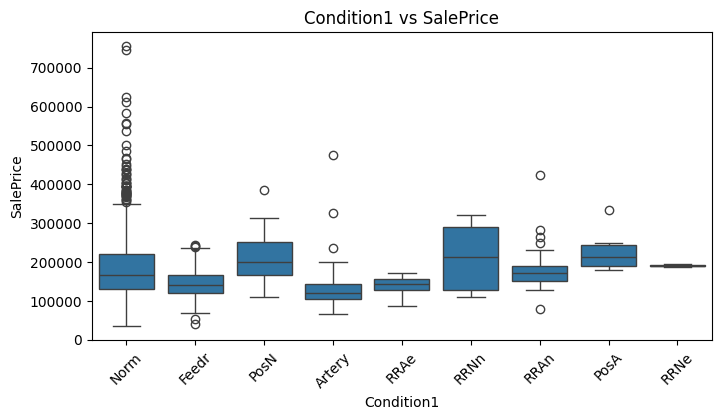

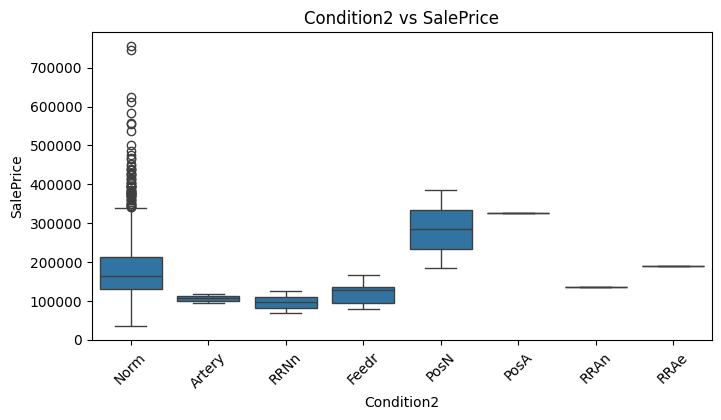

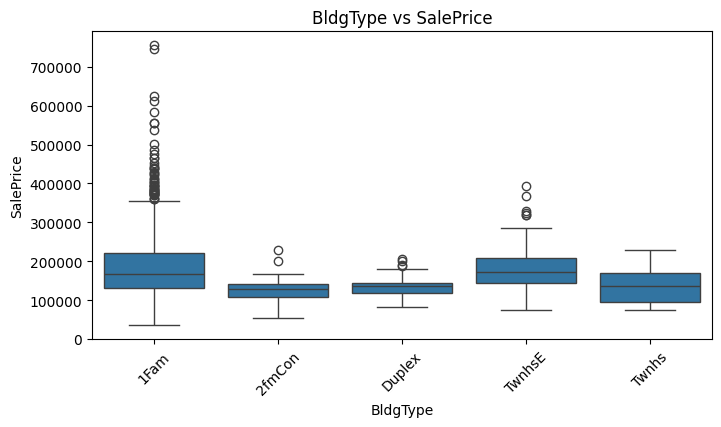

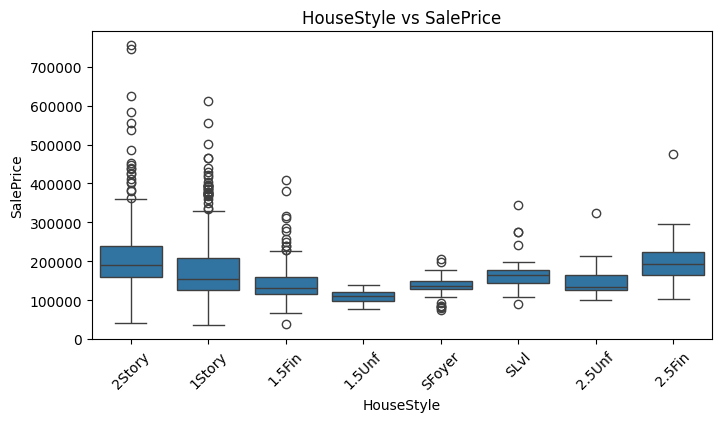

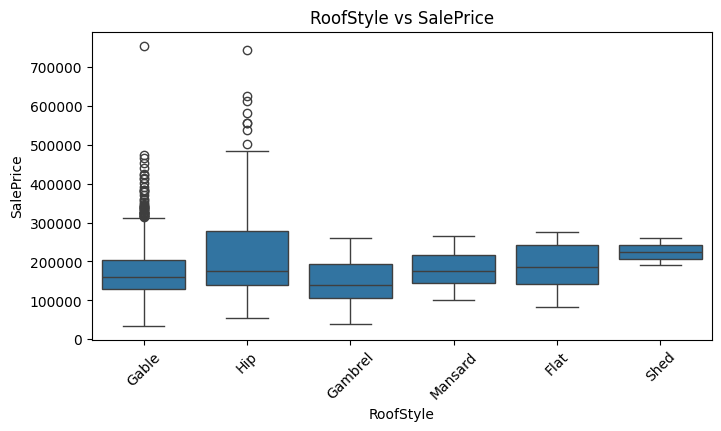

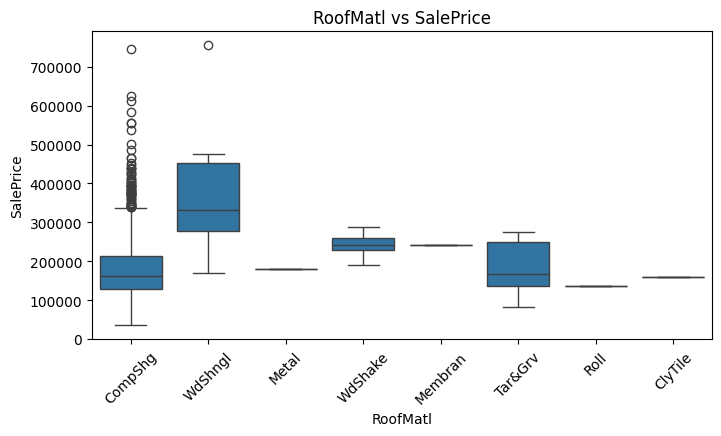

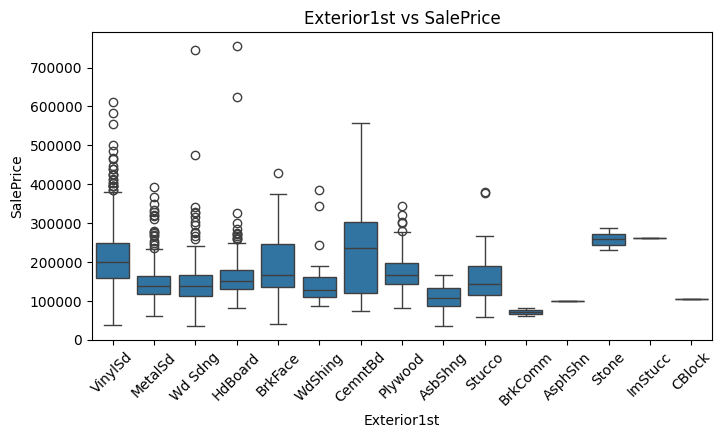

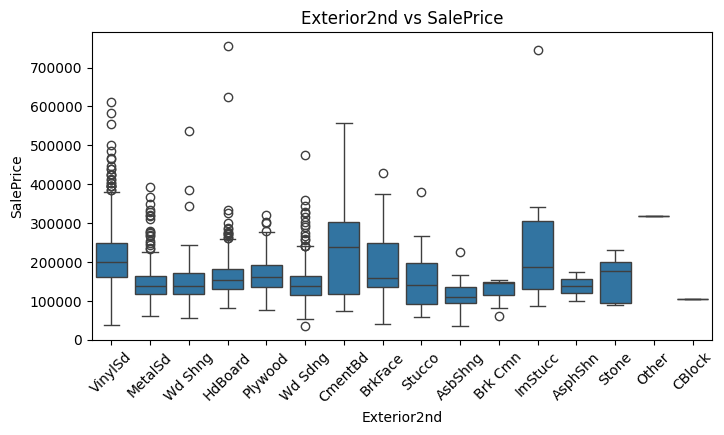

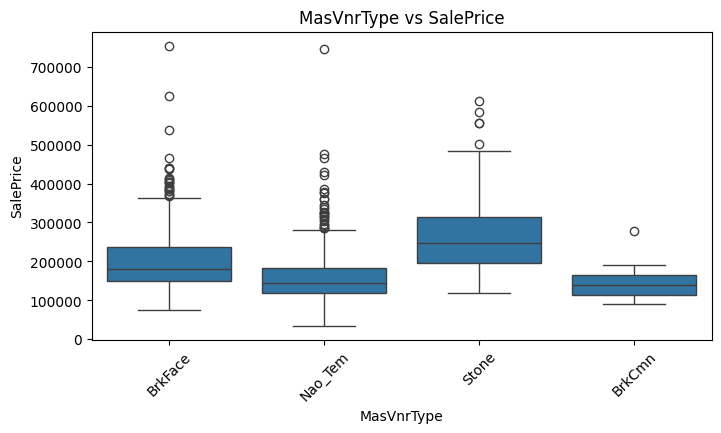

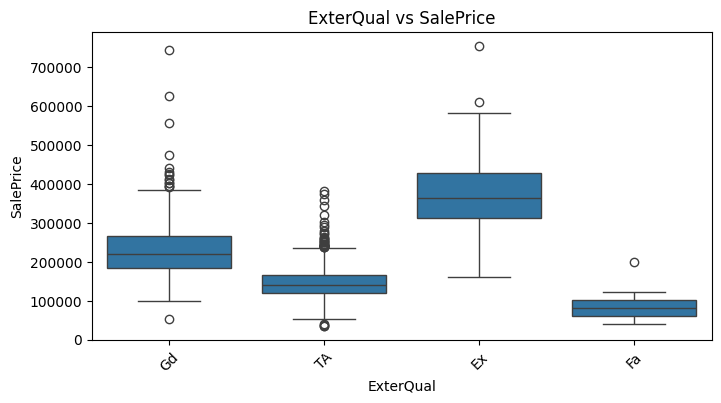

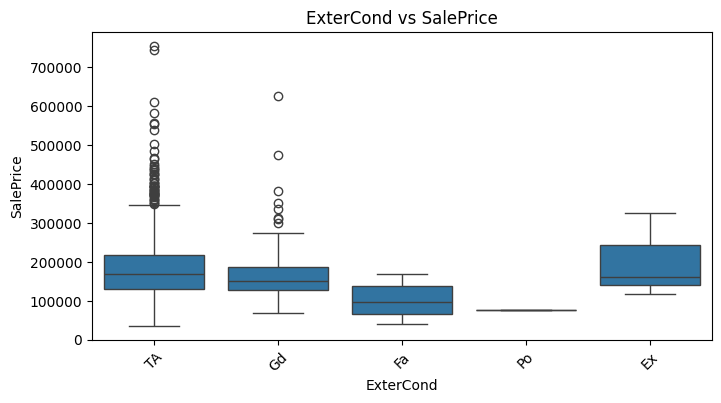

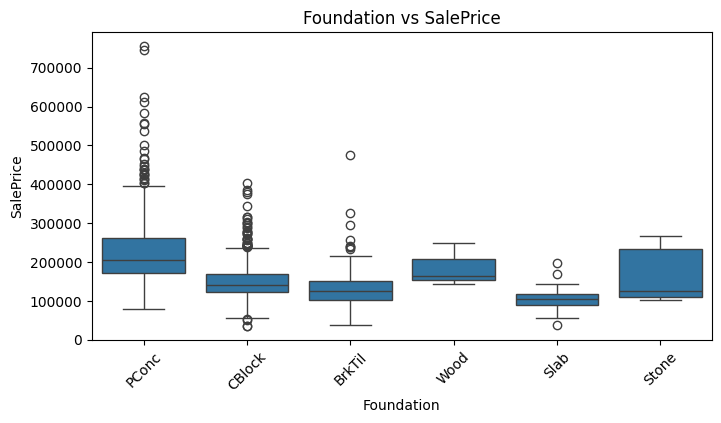

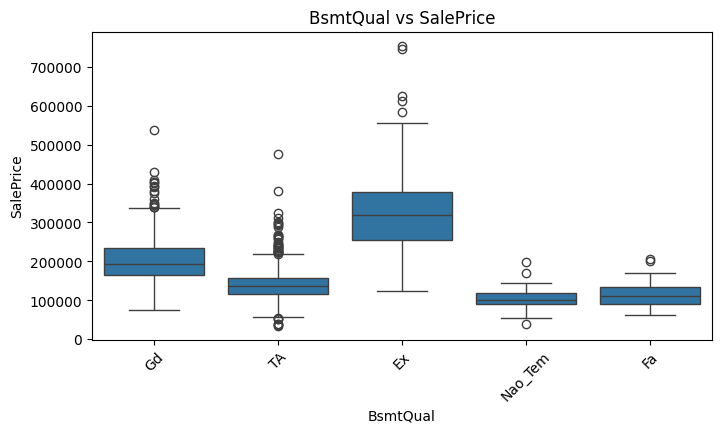

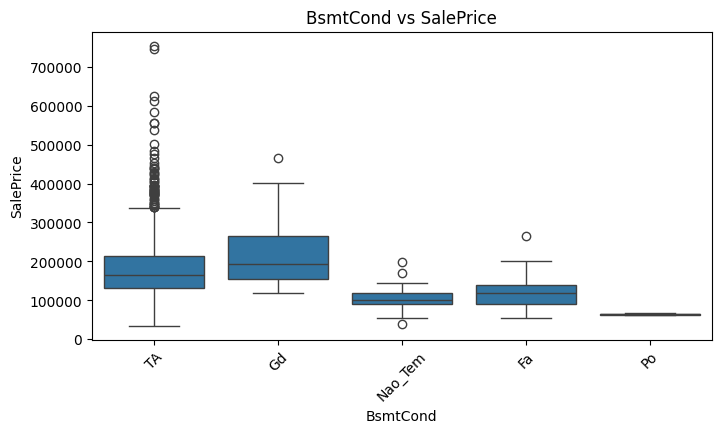

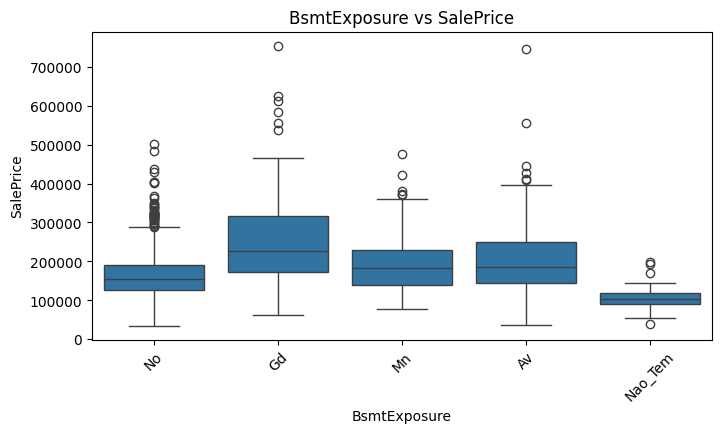

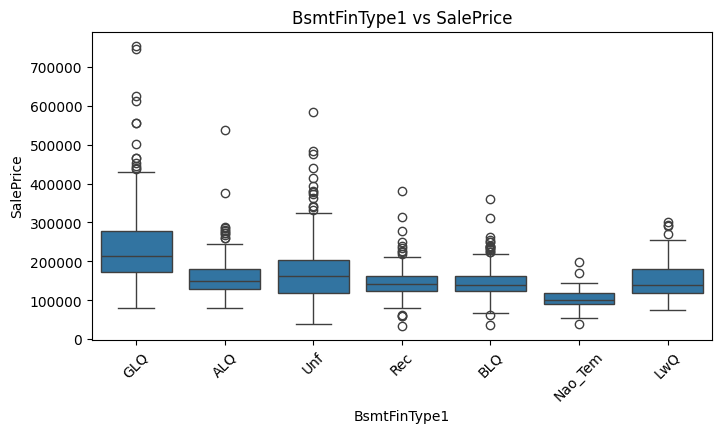

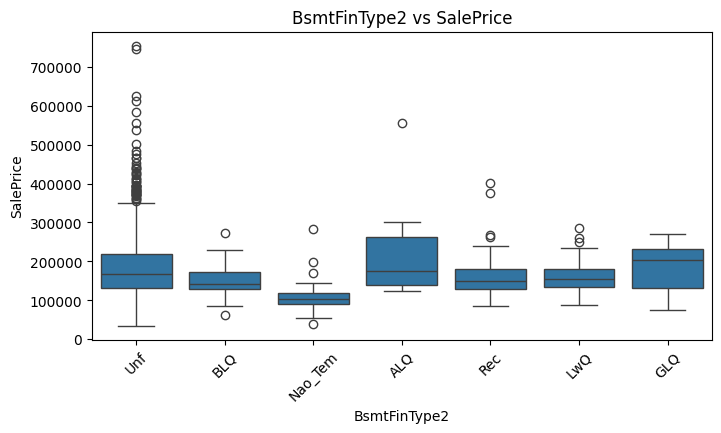

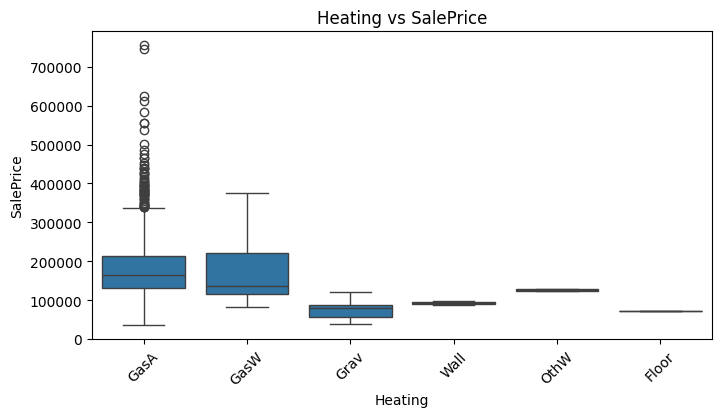

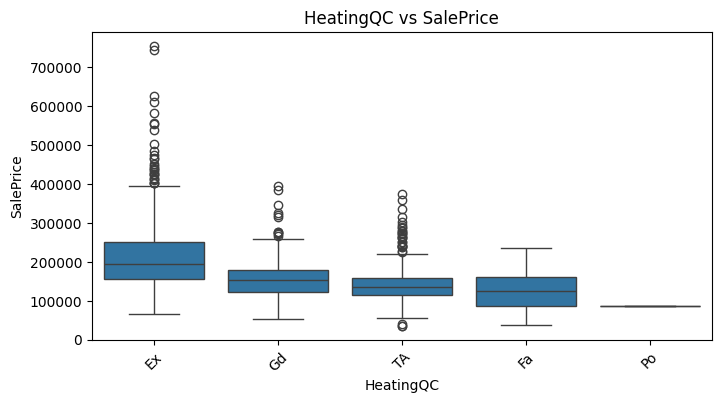

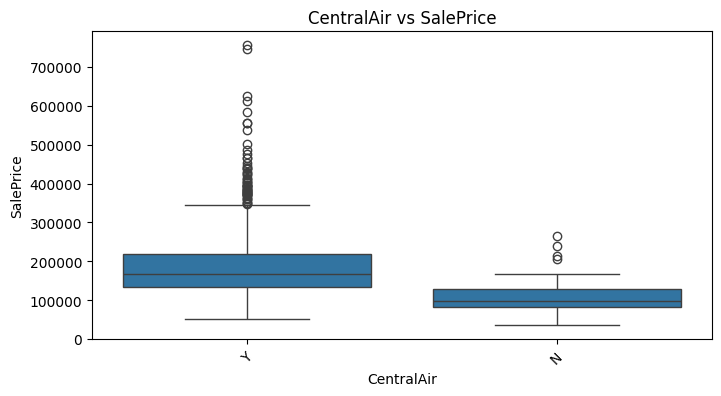

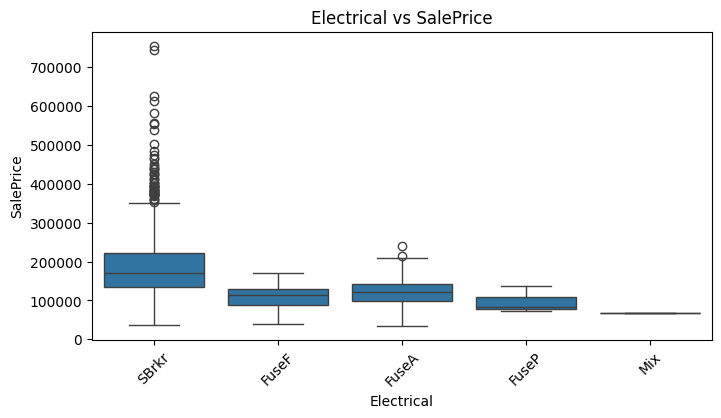

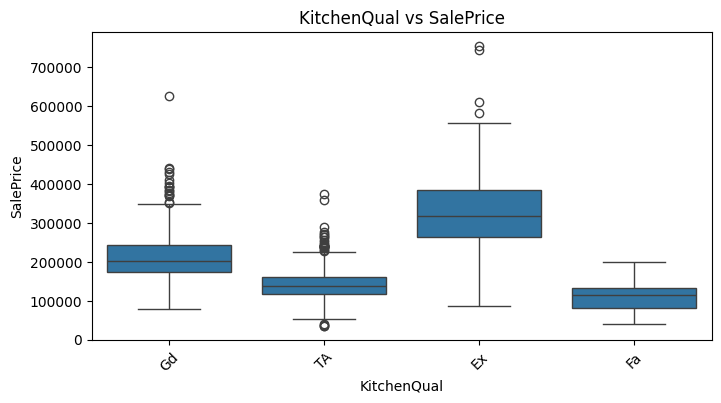

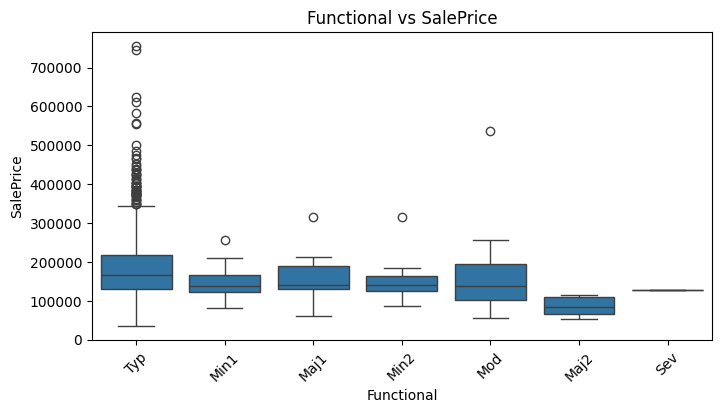

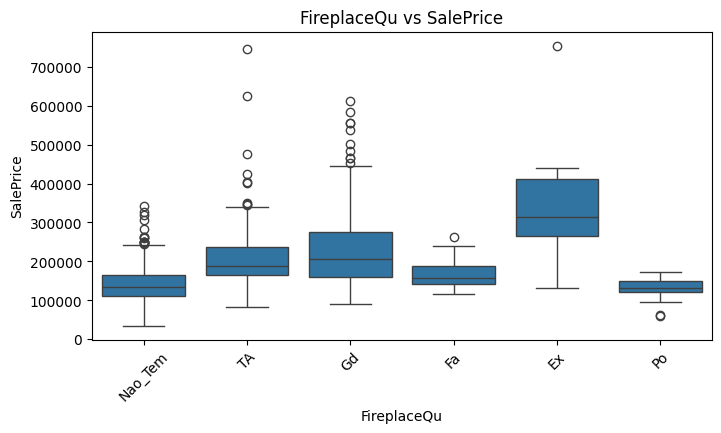

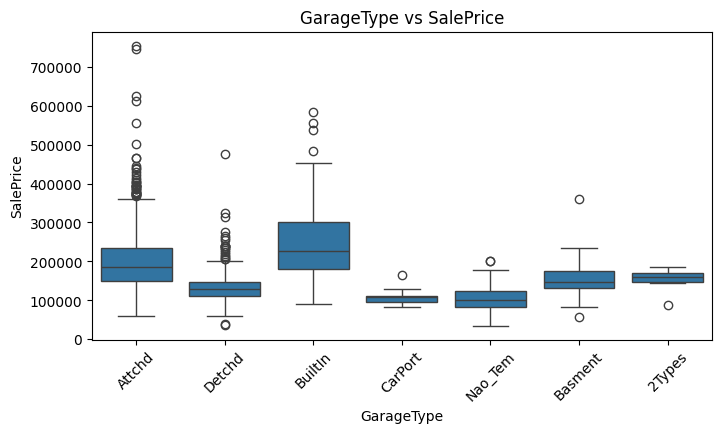

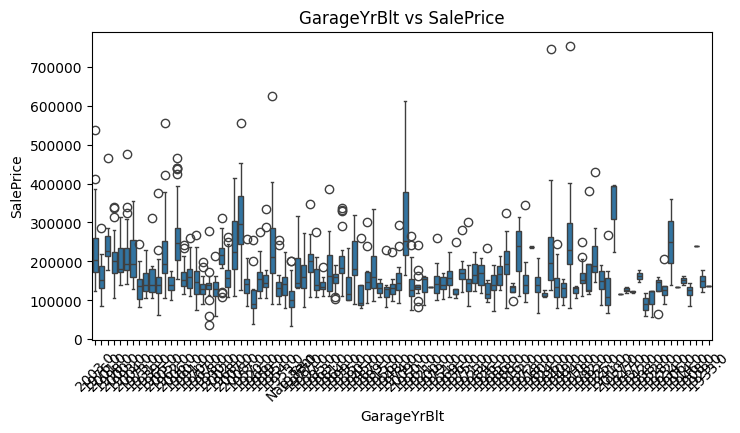

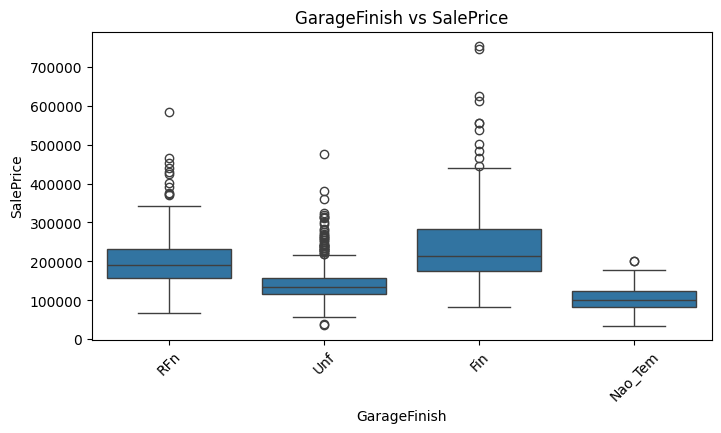

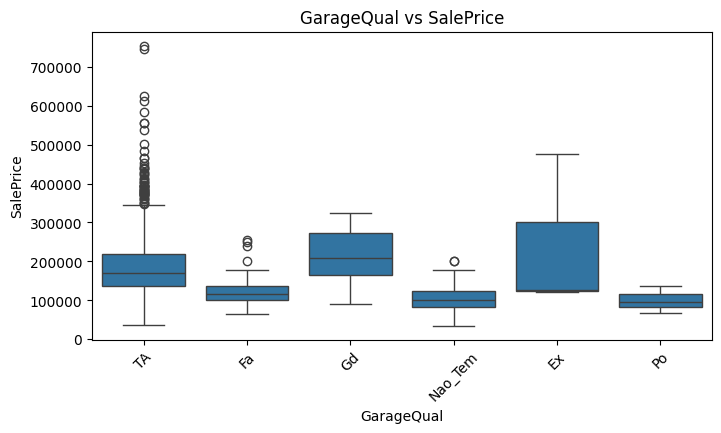

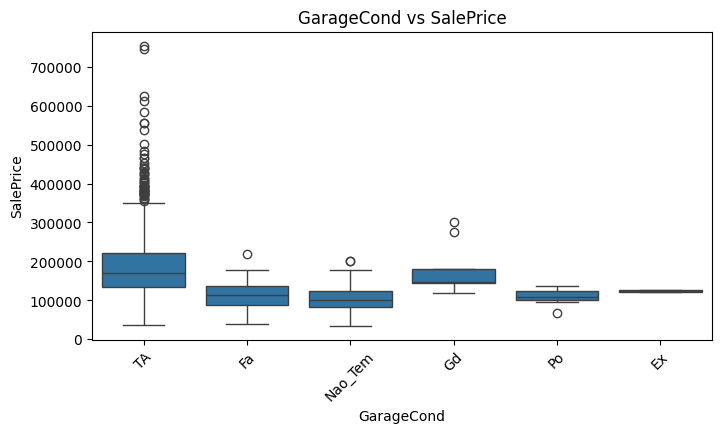

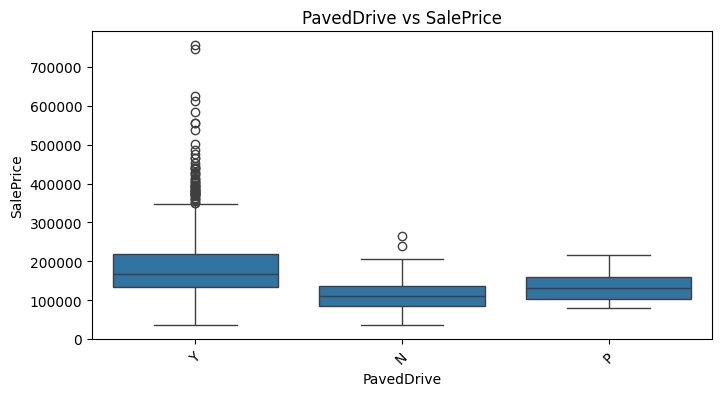

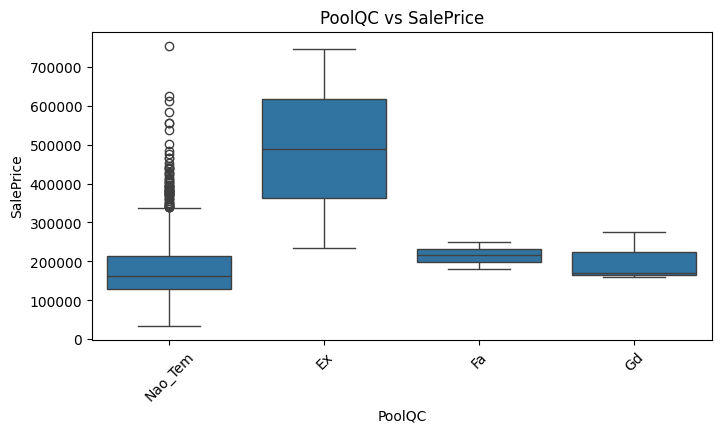

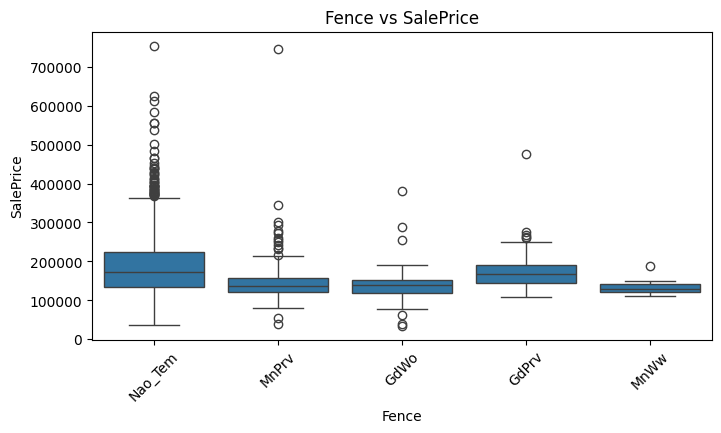

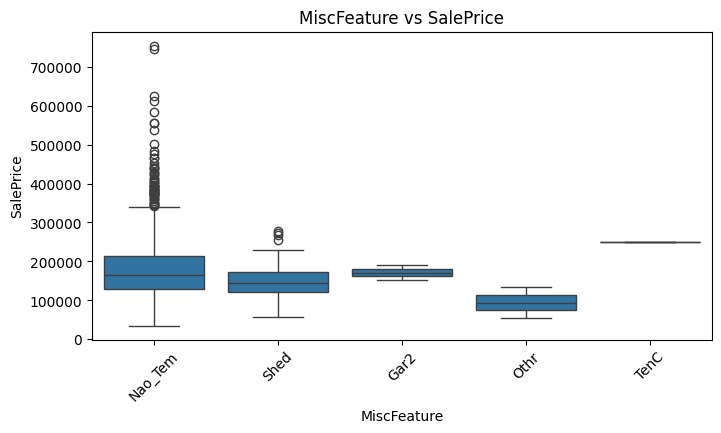

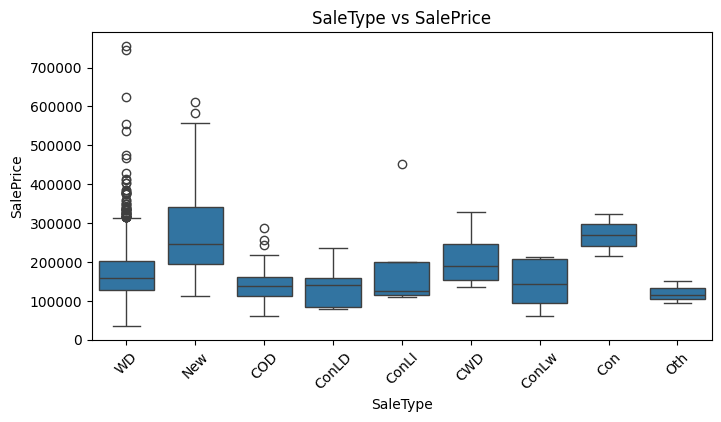

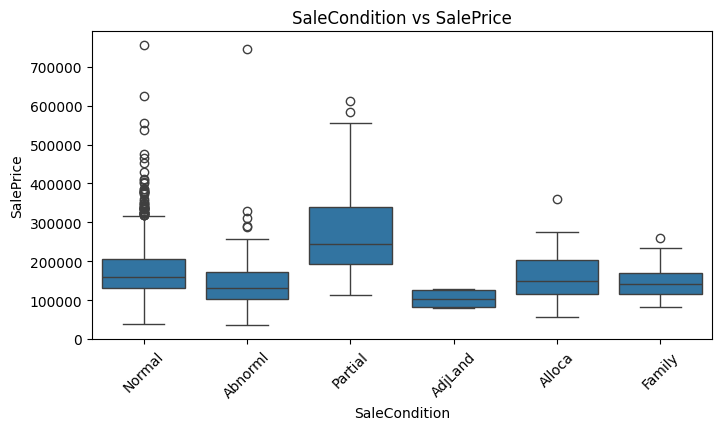

In [67]:
#Análise Variáveis Qualitativas x Preço:

variaveis_quali = ['MSZoning','Street','Alley','LotShape','LandContour','Utilities','LotConfig','LandSlope','Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType','ExterQual','ExterCond','Foundation','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Heating','HeatingQC','CentralAir','Electrical','KitchenQual','Functional','FireplaceQu','GarageType','GarageYrBlt','GarageFinish','GarageQual','GarageCond','PavedDrive','PoolQC','Fence','MiscFeature','SaleType','SaleCondition']

for col in variaveis_quali:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=base_text, x=col, y='SalePrice')
    plt.title(f'{col} vs SalePrice')
    plt.xticks(rotation=45)
    plt.show()


Variáveis Qualitativas com boa correlação no preço


Street

Neighborhood

Condition1

Condition2

RoofMati

Exterior1st

Exterior2nd

ExterQual

BsmtQual

HeatingQC

CentralAir

KithcenQual

FireplaceQu

GarageTypoe

PoolQC

SaleType

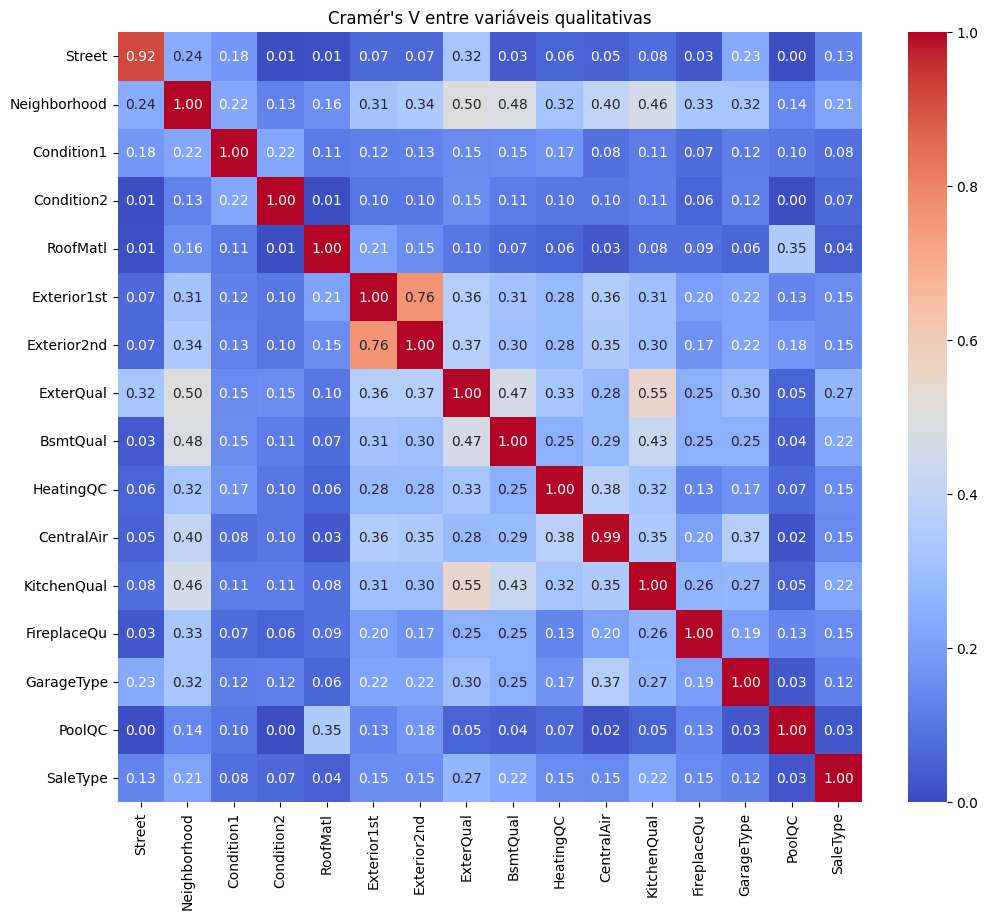

In [68]:
#Verificando se a dependência entre elas via correlação de pearson:

import pandas as pandas_lib
from scipy.stats import chi2_contingency

candidatas2 = ['Street','Neighborhood','Condition1','Condition2','RoofMatl','Exterior1st','Exterior2nd','ExterQual','BsmtQual','HeatingQC','CentralAir','KitchenQual','FireplaceQu','GarageType','PoolQC','SaleType']

# ================================
# Cramér's V para variáveis qualitativas
# ================================

# Função para calcular Cramér's V
def cramers_v(x, y):
    tabela = pandas_lib.crosstab(x, y)
    chi2 = chi2_contingency(tabela)[0]
    n = tabela.sum().sum()
    r, k = tabela.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


# Cálculo da matriz de Cramér's V
cramers_matrix = pd.DataFrame(
    index=candidatas2,
    columns=candidatas2
)

for col1 in candidatas2:
    for col2 in candidatas2:
        cramers_matrix.loc[col1, col2] = cramers_v(base_text[col1], base_text[col2])

cramers_matrix = cramers_matrix.astype(float)

# Visualização
plt.figure(figsize=(12,10))
sns.heatmap(
    cramers_matrix,
    annot=True,          # mostra os valores
    fmt='.2f',           # 2 casas decimais
    cmap='coolwarm',
    vmin=0,
    vmax=1
)
plt.title("Cramér's V entre variáveis qualitativas")
plt.show()


Vamos remover: Exterior2nd,ExterQual,CentralAir,BsmtQual

## FAZENDO O MODELO

In [69]:
variaveis_modelo = ['OverallQual','YearBuilt','TotalBsmtSF','GrLivArea','FullBath','GarageArea','Street','Neighborhood','Condition1','Condition2','RoofMatl','Exterior1st','ExterQual','HeatingQC','KitchenQual','FireplaceQu','GarageType','PoolQC','SaleType','SalePrice']
base_modelo = base[variaveis_modelo]
base_modelo.head()

,OverallQual,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,GarageArea,Street,Neighborhood,Condition1,Condition2,RoofMatl,Exterior1st,ExterQual,HeatingQC,KitchenQual,FireplaceQu,GarageType,PoolQC,SaleType,SalePrice
0,7,2003,856,1710,2,548,Pave,CollgCr,Norm,Norm,CompShg,VinylSd,Gd,Ex,Gd,Nao_Tem,Attchd,Nao_Tem,WD,208500
1,6,1976,1262,1262,2,460,Pave,Veenker,Feedr,Norm,CompShg,MetalSd,TA,Ex,TA,TA,Attchd,Nao_Tem,WD,181500
2,7,2001,920,1786,2,608,Pave,CollgCr,Norm,Norm,CompShg,VinylSd,Gd,Ex,Gd,TA,Attchd,Nao_Tem,WD,223500
3,7,1915,756,1717,1,642,Pave,Crawfor,Norm,Norm,CompShg,Wd Sdng,TA,Gd,Gd,Gd,Detchd,Nao_Tem,WD,140000
4,8,2000,1145,2198,2,836,Pave,NoRidge,Norm,Norm,CompShg,VinylSd,Gd,Ex,Gd,TA,Attchd,Nao_Tem,WD,250000


Preparando as variáveis qualitativas para o modelo:

A maioria dos modelos só recebem carga númérica, portanto as do tipo texto precisam se transformar em número.
A variável qualtitativa pode ser dividida em 2: Ordinal e Categórica. As de ordinal, podem ser substituidas por números, já que representam um ranking. As categóricas, são um pouco mais complexas.

In [70]:
verificacao_ordinal = ['GarageArea','Street','Neighborhood','Condition1','Condition2','RoofMatl','Exterior1st','ExterQual','HeatingQC','KitchenQual','FireplaceQu','GarageType','PoolQC','SaleType','SalePrice']

for col in verificacao_ordinal:
  print(base_modelo.value_counts(col))


GarageArea
0       81
440     49
576     47
240     38
484     34
        ..
1220     1
1248     1
1356     1
1390     1
1418     1
Name: count, Length: 441, dtype: int64
Street
Pave    1454
Grvl       6
Name: count, dtype: int64
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64
Condition1
Norm      1260
Feedr       81
Artery      48
RRAn        26
PosN        19
RRAe        11
PosA         8
RRNn         5
RRNe         2
Name: count, dtype: int64
Condition2
Norm      1445
Feedr        6
Artery       2
PosN         2
RRNn         2
PosA         1
RRAe         1
RRAn         1
Name: count, dtype: int64
RoofMatl
CompShg    1434
Ta

In [71]:
quali_ordinal = {'Nao_Tem': 0,'Po': 1,'Fa': 2,'TA': 3,'Gd': 4,'Ex': 5}

ordinais = ['ExterQual','HeatingQC','KitchenQual','FireplaceQu','PoolQC']

for col in ordinais:
    base_modelo[col] = base_modelo[col].fillna('Nao_Tem').map(quali_ordinal)


/tmp/ipython-input-4250146822.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_modelo[col] = base_modelo[col].fillna('Nao_Tem').map(quali_ordinal)
/tmp/ipython-input-4250146822.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_modelo[col] = base_modelo[col].fillna('Nao_Tem').map(quali_ordinal)
/tmp/ipython-input-4250146822.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [72]:
base_modelo.head(3)

,OverallQual,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,GarageArea,Street,Neighborhood,Condition1,Condition2,RoofMatl,Exterior1st,ExterQual,HeatingQC,KitchenQual,FireplaceQu,GarageType,PoolQC,SaleType,SalePrice
0,7,2003,856,1710,2,548,Pave,CollgCr,Norm,Norm,CompShg,VinylSd,4,5,4,0,Attchd,0,WD,208500
1,6,1976,1262,1262,2,460,Pave,Veenker,Feedr,Norm,CompShg,MetalSd,3,5,3,3,Attchd,0,WD,181500
2,7,2001,920,1786,2,608,Pave,CollgCr,Norm,Norm,CompShg,VinylSd,4,5,4,3,Attchd,0,WD,223500


Agora, sobre as categóricas, precisamos transformar cada categoria em zeros e uns.

Exemplo:
Uma coluna que fala a cor de um veículo e tem cinza, branco e preto: Precisamos pegar a coluna cor e separar em três colunas: cor_cinza,cor_branco,cor_preto. Caso o carro seja cinza, a coluna cor_cinza tera 1 e as colunas cor_branco e cor_preto tera 0, assim alternativamente entre as 3.

Precisamos fazer dessa maneira, pois os modelos recebem dados quantitativos. Então transformamos cada caracteristica em colunas de tem ou não tem tal característica.

Usamos a função get_dommies, que justamente separa as variaveis categoricas dessa maneira

In [73]:
cols_cat = ['Street','Neighborhood','Condition1','Condition2','RoofMatl','Exterior1st','GarageType','SaleType']

base_modelo_encoded = pd.get_dummies(
    base_modelo,
    columns=cols_cat,
    drop_first=True
)


In [74]:
base_modelo

,OverallQual,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,GarageArea,Street,Neighborhood,Condition1,Condition2,RoofMatl,Exterior1st,ExterQual,HeatingQC,KitchenQual,FireplaceQu,GarageType,PoolQC,SaleType,SalePrice
0,7,2003,856,1710,2,548,Pave,CollgCr,Norm,Norm,CompShg,VinylSd,4,5,4,0,Attchd,0,WD,208500
1,6,1976,1262,1262,2,460,Pave,Veenker,Feedr,Norm,CompShg,MetalSd,3,5,3,3,Attchd,0,WD,181500
2,7,2001,920,1786,2,608,Pave,CollgCr,Norm,Norm,CompShg,VinylSd,4,5,4,3,Attchd,0,WD,223500
3,7,1915,756,1717,1,642,Pave,Crawfor,Norm,Norm,CompShg,Wd Sdng,3,4,4,4,Detchd,0,WD,140000
4,8,2000,1145,2198,2,836,Pave,NoRidge,Norm,Norm,CompShg,VinylSd,4,5,4,3,Attchd,0,WD,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1999,953,1647,2,460,Pave,Gilbert,Norm,Norm,CompShg,VinylSd,3,5,3,3,Attchd,0,WD,175000
1456,6,1978,1542,2073,2,500,Pave,NWAmes,Norm,Norm,CompShg,Plywood,3,3,3,3,Attchd,0,WD,210000
1457,7,1941,1152,2340,2,252,Pave,Crawfor,Norm,Norm,CompShg,CemntBd,5,5,4,4,Attchd,0,WD,266500
1458,5,1950,1078,1078,1,240,Pave,NAmes,Norm,Norm,CompShg,MetalSd,3,4,4,0,Attchd,0,WD,142125


In [75]:
base_modelo_encoded

,OverallQual,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,GarageArea,ExterQual,HeatingQC,KitchenQual,FireplaceQu,...,GarageType_Detchd,GarageType_Nao_Tem,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD
0,7,2003,856,1710,2,548,4,5,4,0,...,False,False,False,False,False,False,False,False,False,True
1,6,1976,1262,1262,2,460,3,5,3,3,...,False,False,False,False,False,False,False,False,False,True
2,7,2001,920,1786,2,608,4,5,4,3,...,False,False,False,False,False,False,False,False,False,True
3,7,1915,756,1717,1,642,3,4,4,4,...,True,False,False,False,False,False,False,False,False,True
4,8,2000,1145,2198,2,836,4,5,4,3,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1999,953,1647,2,460,3,5,3,3,...,False,False,False,False,False,False,False,False,False,True
1456,6,1978,1542,2073,2,500,3,3,3,3,...,False,False,False,False,False,False,False,False,False,True
1457,7,1941,1152,2340,2,252,5,5,4,4,...,False,False,False,False,False,False,False,False,False,True
1458,5,1950,1078,1078,1,240,3,4,4,0,...,False,False,False,False,False,False,False,False,False,True


## Fazendo o modelo:

Testando via Método dos Mínimos Quadrados através da Regressão Linear:

O treino do modelo utiliza o Método dos Mínimos Quadrados para achar os melhores coeficientes.

Reglin: Y = aX + b + k (k = erro)

k: Y - E(Y∣X) = A média de Y com os valores observados em X. (Real - Média)

Usamos o método RMSE, a raiz do erro quadrádito médio. (valores previstos x valores observados)

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
# =========================
# 4) Separar X e y + treino/teste
# =========================
X = base_modelo_encoded.drop(columns=['SalePrice'])
y = base_modelo_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1239380882)

# =========================
# 5) Treinar OLS (Mínimos Quadrados)
# =========================
modelo_ols = LinearRegression()
modelo_ols.fit(X_train, y_train)

# =========================
# 6) Avaliar (RMSE)
# =========================
y_pred = modelo_ols.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE (teste): {rmse:,.2f}")

RMSE (teste): 29,232.01


Podemos ajustar a função original, dizendo que em vez de Y = aX+b+k, usaremos: log(Y)=aX+b+k

Dessa forma aplicamos:

e^log(Y) = e^(aX+b+k)

Y = e^aX*e^b*e^k


Dessa forma, conseguimos deixar o erro proporcional ao valor estimado. (Em vez de ser um valor fixo k, o erro esta multiplicativo devido ao exponencial)

Assim, conseguiremos usar uma função com erro proporcional aos valores, e não fixo (o que pode extrapolar o valor das casas)

In [77]:
y = np.log1p(base_modelo_encoded['SalePrice'])
X = base_modelo_encoded.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin = LinearRegression()
lin.fit(X_train, y_train)

pred_log = lin.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
print("RMSE no log:", rmse_log)


RMSE no log: 0.21610515411670347


Dado que estamos na base log, o RMSE de 0.2166105 significa que temos que fazer: e^0.216105... = 124%, ou seja, estamos 24% acima dos valors da casa.

Dado que anteriormente chegamos em um valor fixo de 29,232 (16% da média das casas), o modelo sem ajustes logisticos se provou melhor.

In [78]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

pred = ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE Ridge:", rmse)



RMSE Ridge: 0.1536160009340336


O Modelo Ridge é uma regresão linear com outro tipo de penalização (diferente dos mínimos quadrad0s). neste caso, o ridge penaliza a magnitude dos coeficientes.